# Fama-French Panel Analysis Across Sectors

This notebook reorganizes the original assignment into a cleaner empirical workflow. The focus is on daily stock excess returns, sector differences, and Fama-French factor exposure across a panel of firms.

## Modeling Setup

For each stock $i$ and date $t$, I compute the simple return

$$
R_{i,t} = rac{P_{i,t}}{P_{i,t-1}} - 1
$$

and then form the excess return

$$
R^e_{i,t} = R_{i,t} - r_{f,t}.
$$

The main regression is the Fama-French three-factor model

$$
R^e_{i,t} = lpha_i + eta_{i,m} MKT_t + eta_{i,s} SMB_t + eta_{i,h} HML_t + arepsilon_{i,t}.
$$

A key cleanup in this version is that the factor data are converted from percent units to decimal units before estimation.

In [1]:
from pathlib import Path
import sys

import pandas as pd
from IPython.display import Image, display

PROJECT_DIR = Path.cwd().resolve().parent
sys.path.append(str(PROJECT_DIR / "src"))

from analysis import run_analysis, tidy_model

pd.set_option("display.float_format", lambda value: f"{value:0.4f}")
results = run_analysis(PROJECT_DIR)
panel = results["panel"]
sector_summary = results["sector_summary"]
loadings = results["loadings"]
loadings_summary = results["loadings_summary"]


## Panel Overview

The original notebook mixed data cleaning, filtering, and regression code together. Here the panel is built once, then reused consistently across the models.

In [2]:
print({
    "observations": len(panel),
    "tickers": panel["Ticker"].nunique(),
    "dates": panel["Date"].nunique(),
})

sector_summary

{'observations': 476226, 'tickers': 123, 'dates': 3895}


,n_stocks,observations,mean_excess_return,volatility
sector,,,,
Basic Materials,19,73926,0.0005,0.0209
Communication Services,19,73405,0.0007,0.0212
Consumer Cyclical,52,200360,0.0007,0.0221
Consumer Defensive,33,128535,0.0005,0.0148


## Pooled Factor Models

I first compare a one-factor CAPM benchmark with the three-factor Fama-French model. This shows whether size and value exposure add explanatory power in the pooled panel.

In [3]:
capm_table = tidy_model(results["capm"], "CAPM", ["Intercept", "mkt_excess"])
ff3_table = tidy_model(results["ff3"], "FF3", ["Intercept", "mkt_excess", "smb", "hml"])
pd.concat([capm_table, ff3_table], ignore_index=True)

,model,term,coefficient,std_error,t_stat,p_value,r_squared
0,CAPM,Intercept,0.0001,0.0000,5.9638,0.0000,0.2662
1,CAPM,mkt_excess,0.9143,0.0041,224.0669,0.0000,0.2662
2,FF3,Intercept,0.0002,0.0000,7.0898,0.0000,0.2728
3,FF3,mkt_excess,0.8963,0.0043,207.3357,0.0000,0.2728
4,FF3,smb,0.1307,0.0061,21.5171,0.0000,0.2728
5,FF3,hml,0.1835,0.0051,35.9976,0.0000,0.2728


## Sector Effects And Firm Heterogeneity

The next comparison keeps the same factor structure but checks whether sector differences and firm-specific effects change the factor estimates materially.

In [4]:
sector_table = tidy_model(
    results["sector_effects"],
    "Sector Effects",
    [
        "Intercept",
        "C(sector)[T.Communication Services]",
        "C(sector)[T.Consumer Cyclical]",
        "C(sector)[T.Consumer Defensive]",
        "mkt_excess",
        "smb",
        "hml",
    ],
)
fe_table = tidy_model(
    results["ticker_fixed_effects"],
    "Ticker Fixed Effects",
    ["mkt_excess", "smb", "hml"],
)
pd.concat([sector_table, fe_table], ignore_index=True)

,model,term,coefficient,std_error,t_stat,p_value,r_squared
0,Sector Effects,Intercept,0.0001,0.0001,1.2867,0.1982,0.2728
1,Sector Effects,C(sector)[T.Communication Services],0.0002,0.0001,1.9969,0.0458,0.2728
2,Sector Effects,C(sector)[T.Consumer Cyclical],0.0002,0.0001,2.8620,0.0042,0.2728
3,Sector Effects,C(sector)[T.Consumer Defensive],-0.0001,0.0001,-1.0390,0.2988,0.2728
4,Sector Effects,mkt_excess,0.8963,0.0043,207.3098,0.0000,0.2728
5,Sector Effects,smb,0.1307,0.0061,21.5209,0.0000,0.2728
6,Sector Effects,hml,0.1835,0.0051,36.0008,0.0000,0.2728
7,Ticker Fixed Effects,mkt_excess,0.8963,0.0043,207.2767,0.0000,0.2728
8,Ticker Fixed Effects,smb,0.1307,0.0061,21.5238,0.0000,0.2728
9,Ticker Fixed Effects,hml,0.1835,0.0051,35.9958,0.0000,0.2728


## Firm-Level Loadings

A useful way to make the panel interpretation more concrete is to estimate the factor loadings stock by stock and then summarize them by sector.

In [5]:
loadings_summary

,alpha,beta_mkt,beta_smb,beta_hml,average_r_squared
sector,,,,,
Basic Materials,0.0000,1.0385,0.2189,0.4440,0.4198
Communication Services,0.0002,0.9387,0.1033,-0.0068,0.3283
Consumer Cyclical,0.0002,1.0338,0.3207,0.1948,0.3556
Consumer Defensive,0.0002,0.5821,-0.1959,0.1298,0.2230


In [6]:
loadings.nlargest(10, "beta_mkt")[["Ticker", "sector", "beta_mkt", "beta_smb", "beta_hml", "r_squared"]]

,Ticker,sector,beta_mkt,beta_smb,beta_hml,r_squared
71,NCLH,Consumer Cyclical,1.5981,1.0359,0.8100,0.3539
6,FCX,Basic Materials,1.5581,0.4506,0.7309,0.3864
77,RCL,Consumer Cyclical,1.5431,0.6713,0.6916,0.4227
69,MGM,Consumer Cyclical,1.5365,0.5596,0.5198,0.4504
47,CCL,Consumer Cyclical,1.4432,0.7138,0.7206,0.3840
85,TSLA,Consumer Cyclical,1.4078,0.6494,-0.8061,0.2617
88,WYNN,Consumer Cyclical,1.3393,0.5677,0.4310,0.3442
40,APTV,Consumer Cyclical,1.3061,0.6201,0.3791,0.4644
0,ALB,Basic Materials,1.2758,0.6129,0.2501,0.3872
17,STLD,Basic Materials,1.2420,0.5068,0.8267,0.4716


## Visual Summary

The two figures below show the sector growth paths and the cross-sector distribution of firm-level factor exposures.

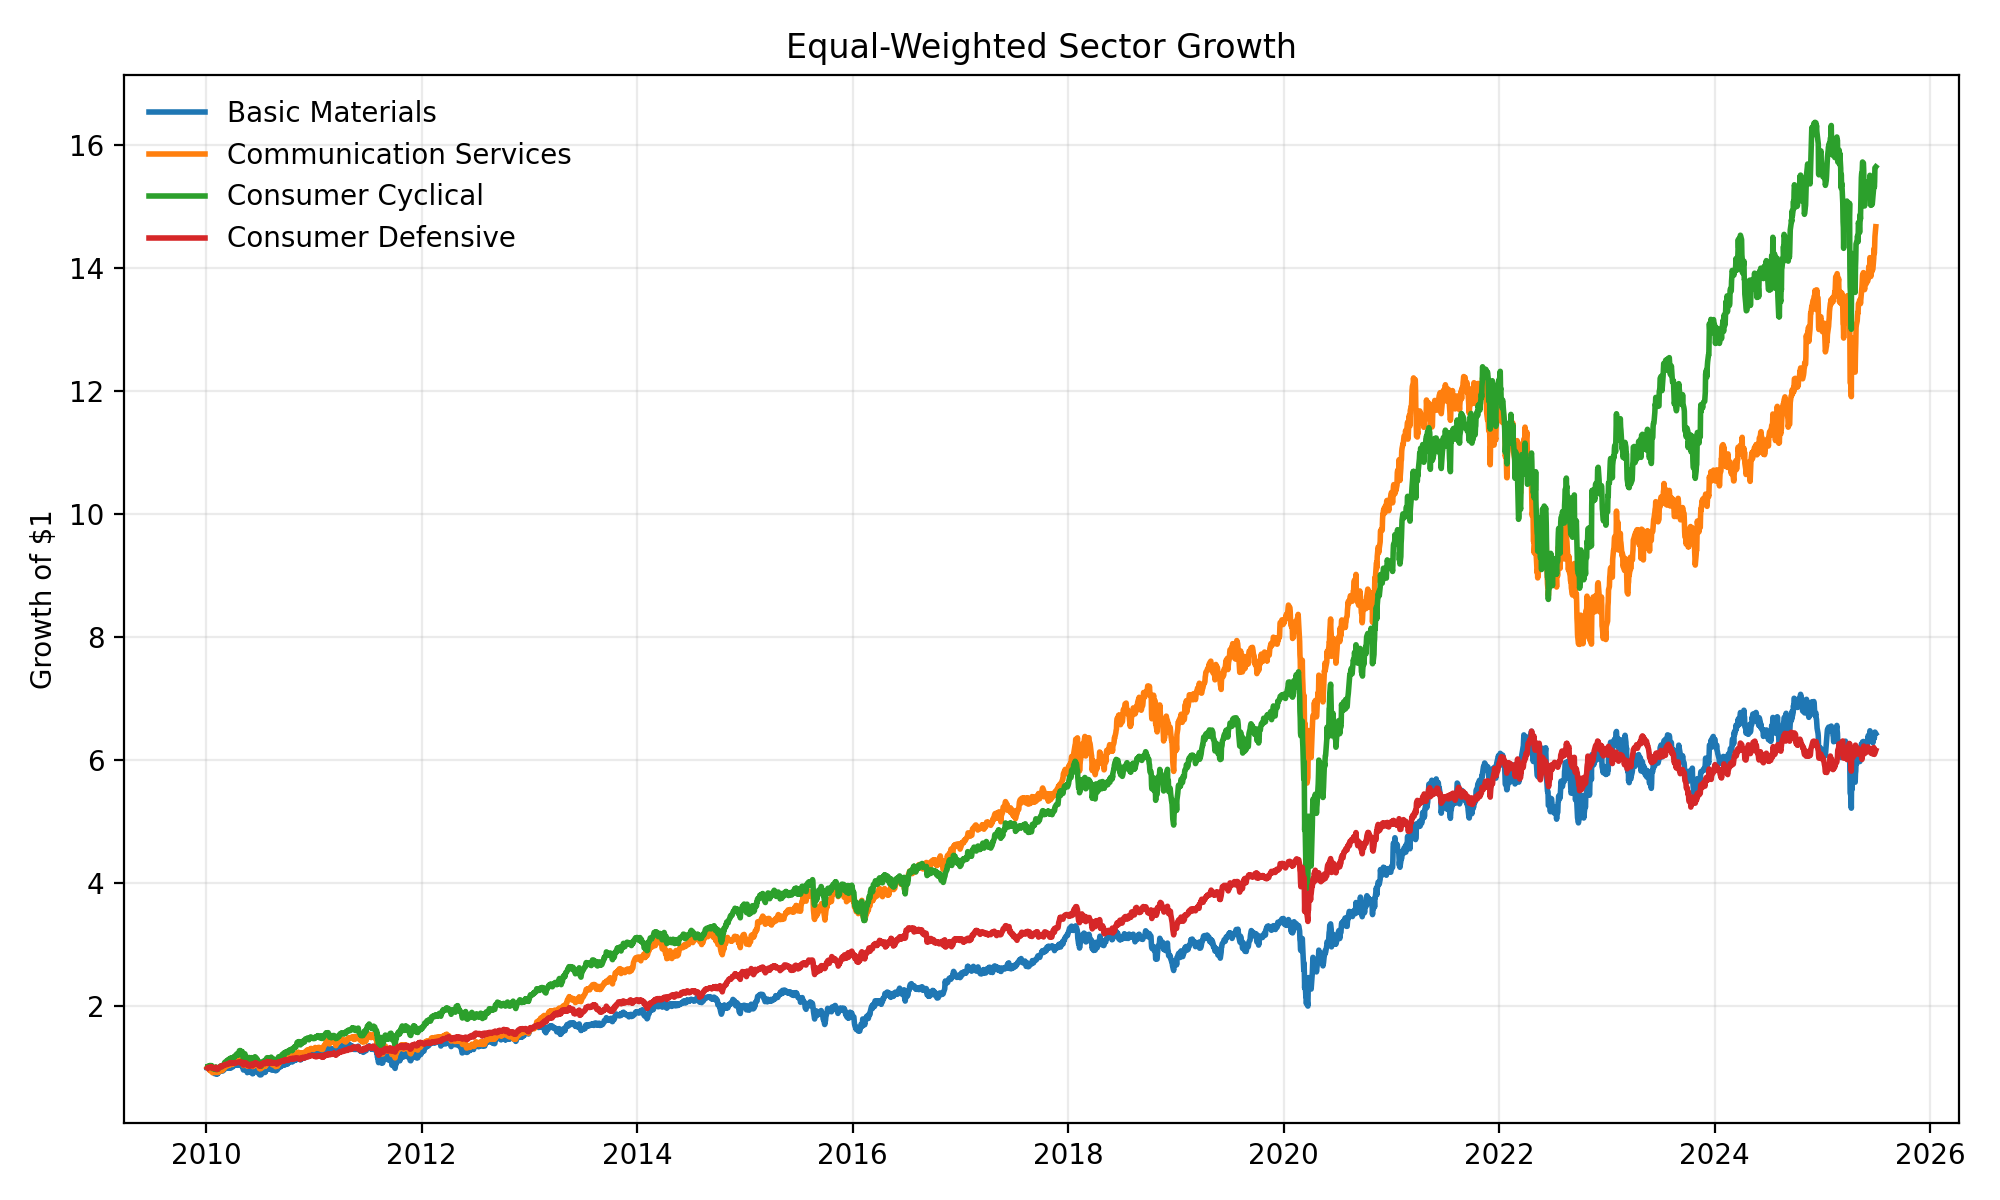

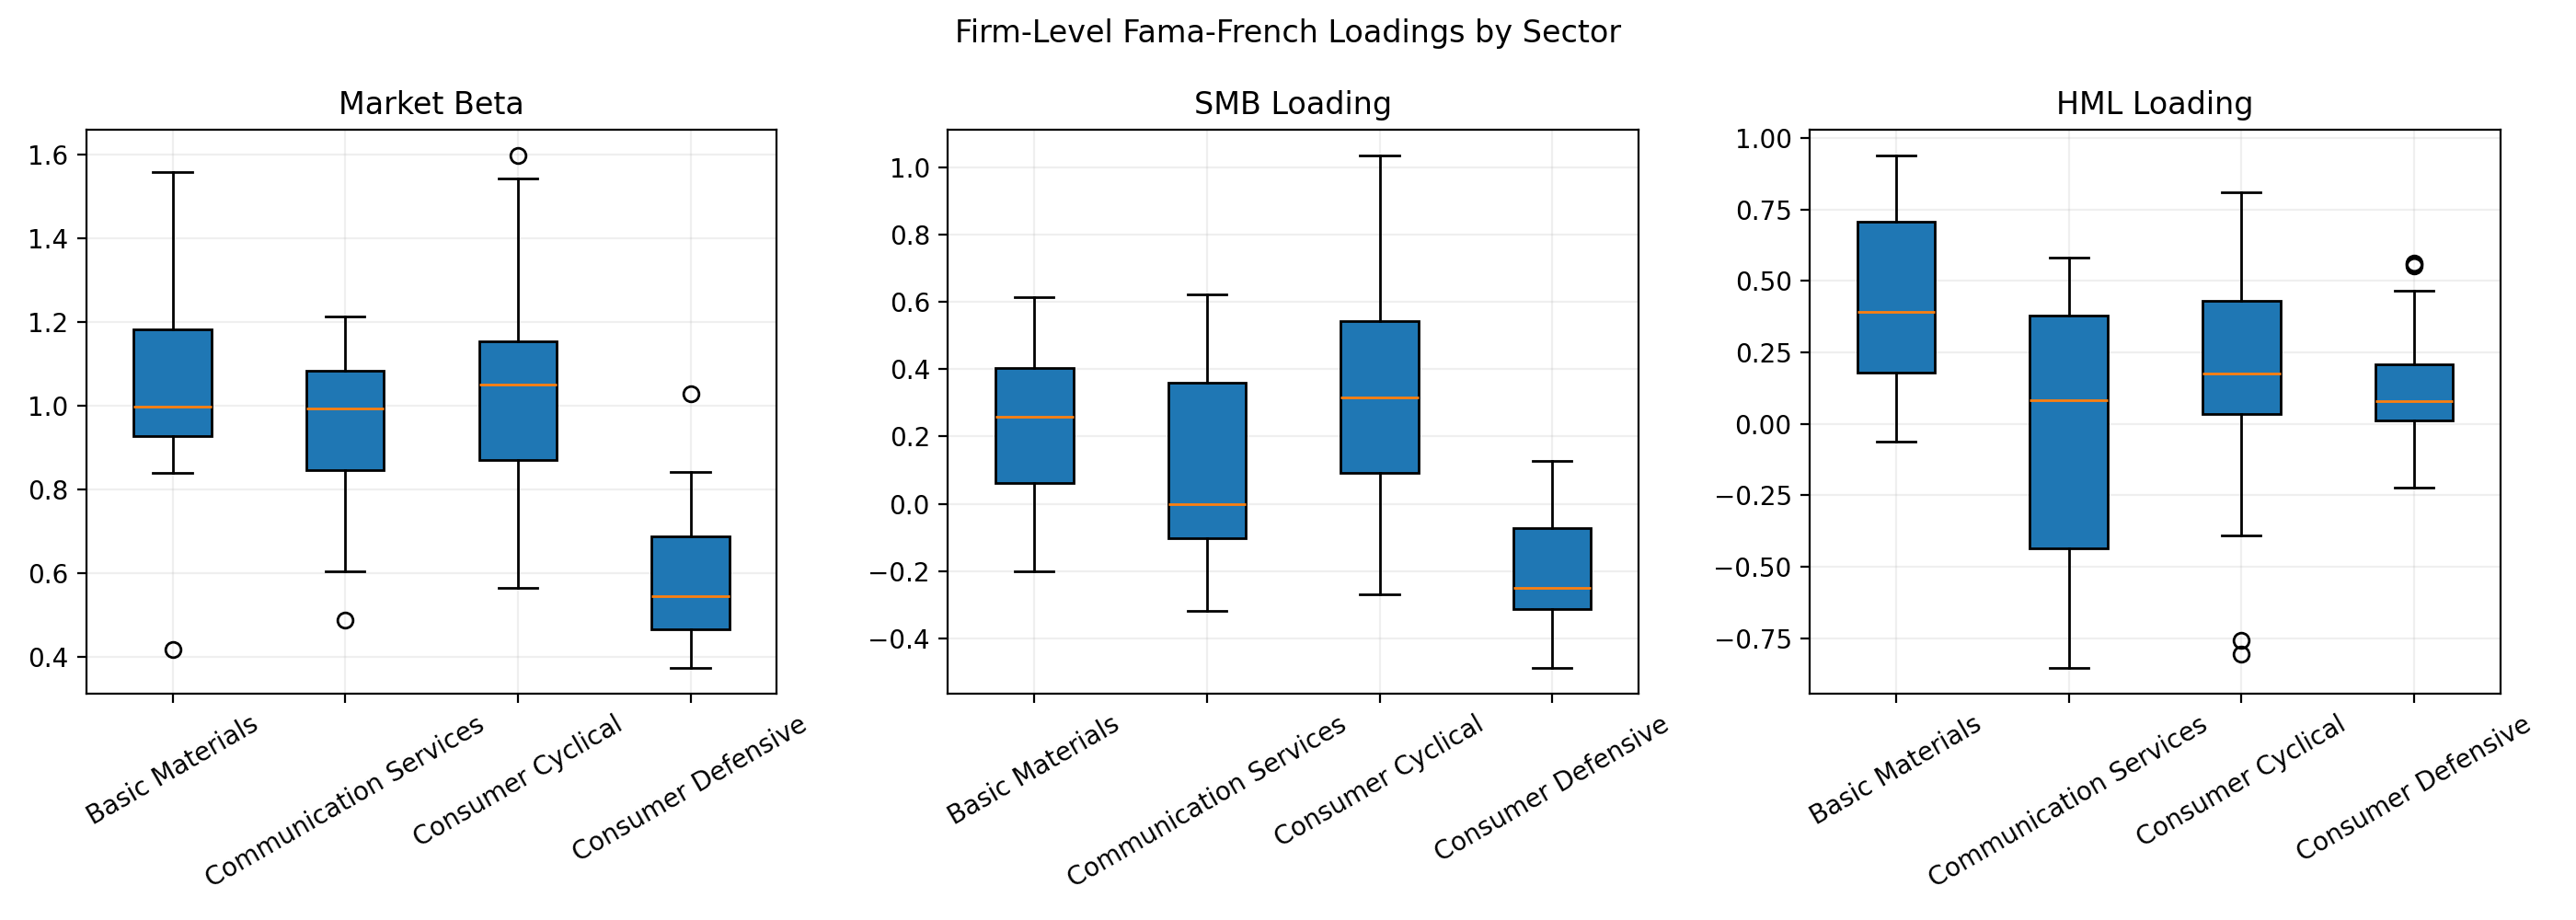

In [7]:
display(Image(filename=str(PROJECT_DIR / "figures" / "sector_cumulative_returns.png")))
display(Image(filename=str(PROJECT_DIR / "figures" / "factor_loadings_by_sector.png")))

## Short Takeaways

- The market factor remains the main driver of average excess returns.
- The three-factor model improves on CAPM, but the increase in $R^2$ is modest rather than dramatic.
- Consumer defensive names carry clearly lower market beta than cyclical and materials firms.
- Basic materials and consumer cyclical stocks tend to show stronger market and size exposure.

Overall, the results show a clear sector pattern: defensive stocks carry lower market exposure, while cyclical and materials names load more strongly on the common factors.